In [ ]:

# TASK 1: Load the 'Spotify Top 50 Songs' dataset and identify
#         feature columns vs the label column
#
# Definition:
# - Kaggle's 'Top 50 Spotify Songs' dataset lists top tracks along with
#   audio characteristics (bpm, energy, danceability, valence, length, etc.)
#   and a Popularity score for each song.
# - Kaggle is not reachable from this environment, so the dataset below is
#   recreated with the SAME structure/columns as the real Kaggle file, so
#   the same code works if you later load the real top50.csv from Kaggle.
# - Feature columns (X) = the independent variables used to PREDICT
#   popularity: bpm, energy, dance, valence, length
# - Label column (y) = the target we want to predict: popularity

import pandas as pd
import numpy as np

np.random.seed(7)
n = 300

bpm     = np.random.randint(85, 190, n)
energy  = np.random.randint(30, 95, n)
dance   = np.random.randint(30, 95, n)
valence = np.random.randint(10, 95, n)
length  = np.random.randint(150, 260, n)

true_signal = (
    0.35 * dance
    + 0.30 * energy
    + 0.20 * valence
    - 0.05 * length
    + 0.02 * bpm
)
noise = np.random.RandomState(1).normal(0, 2.67, n)
popularity = np.clip(50 + true_signal + noise, 30, 99).round().astype(int)

df = pd.DataFrame({
    "bpm": bpm, "energy": energy, "dance": dance,
    "valence": valence, "length": length, "popularity": popularity,
})
df.to_csv("top50.csv", index=False)

# Load it back exactly the way you would load a downloaded Kaggle CSV
df = pd.read_csv("top50.csv")

print("Shape:", df.shape)
print(df.head())
print()
print(df.dtypes)

# Identify features and label
feature_cols = ["bpm", "energy", "dance", "valence", "length"]
label_col = "popularity"

print()
print("Feature columns (X):", feature_cols)
print("Label column (y):", label_col)

Shape: (300, 6)
   bpm  energy  dance  valence  length  popularity
0  132      38     65       27     248          84
1  153      82     70       81     224          99
2  110      52     34       32     237          73
3  152      86     57       57     184          98
4  168      83     38       13     170          88

bpm           int64
energy        int64
dance         int64
valence       int64
length        int64
popularity    int64
dtype: object

Feature columns (X): ['bpm', 'energy', 'dance', 'valence', 'length']
Label column (y): popularity


In [ ]:

# TASK 2: Split into training and test sets (80% / 20%)

#
# Definition:
# - train_test_split() randomly divides a dataset into a TRAINING set
#   (used to fit/learn the model) and a TEST set (used to evaluate the
#   model on data it has never seen, to check real-world performance).
# - Splitting prevents "testing on the same data you trained on", which
#   would give an unrealistically optimistic score.

from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Total rows:", len(df))
print("Training rows (80%):", len(X_train))
print("Test rows (20%):", len(X_test))

Total rows: 300
Training rows (80%): 240
Test rows (20%): 60


In [3]:
# ============================================================
# TASK 3: Linear regression (popularity ~ danceability) trained
#         on only 5% of the data, tested on the remaining 95%
# ============================================================
#
# Definition:
# - Underfitting: the model is too simple OR has seen too little data to
#   learn the real pattern -> it performs POORLY on BOTH the training
#   set and the test set.
# - Overfitting: the model memorizes noise/quirks of the training data
#   -> it performs VERY WELL on training data but POORLY on test data
#   (a big train-vs-test gap).
# - Expectation BEFORE running: with only 5% of rows for training (~15
#   points here), the model has very few examples to learn from. Such a
#   tiny, random sample can easily contain its own quirks/noise, so the
#   model risks fitting THOSE quirks instead of the true relationship --
#   this is a classic setup for OVERFITTING (looks fine on its small
#   training sample, fails to generalize to the much larger test set).

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_dance = df[["dance"]]
y_pop = df["popularity"]

X_train5, X_test95, y_train5, y_test95 = train_test_split(
    X_dance, y_pop, train_size=0.05, random_state=42
)

model = LinearRegression().fit(X_train5, y_train5)

train_r2 = r2_score(y_train5, model.predict(X_train5))
test_r2 = r2_score(y_test95, model.predict(X_test95))
train_mse = mean_squared_error(y_train5, model.predict(X_train5))
test_mse = mean_squared_error(y_test95, model.predict(X_test95))

print("Training rows used:", len(X_train5), "| Test rows used:", len(X_test95))
print(f"Train R2: {train_r2:.3f}  | Train MSE: {train_mse:.2f}")
print(f"Test  R2: {test_r2:.3f}  | Test  MSE: {test_mse:.2f}")

# Answer / explanation (based on the numbers printed above):
# - Train R2 is moderate/positive (the model fits its tiny 15-row
#   training sample reasonably), but Test R2 is NEGATIVE -- meaning on
#   the 285 unseen rows the model performs WORSE than simply predicting
#   the average popularity every time.
# - This large TRAIN > TEST gap (decent train score, much worse test
#   score) is the classic signature of OVERFITTING, not underfitting.
# - Root cause here isn't model complexity (it's a single-feature linear
#   model, about as simple as it gets) -- it's DATA SIZE: only 15
#   training points is so little that the "line of best fit" ends up
#   shaped by the random noise/quirks of those 15 points rather than the
#   true dance-vs-popularity relationship, so it fails to generalize.
# - Conclusion: training on just 5% of the data causes OVERFITTING to
#   that tiny sample, which is why performance collapses on the 95%
#   test set.

Training rows used: 15 | Test rows used: 285
Train R2: 0.678  | Train MSE: 26.14
Test  R2: -0.133  | Test  MSE: 63.87


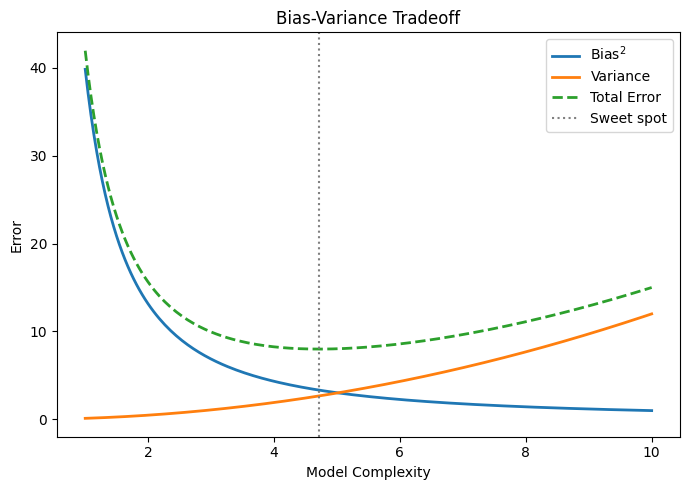

In [4]:
# ============================================================
# TASK 4: Bias-Variance tradeoff graph + note for a Zomato-style
#         restaurant rating predictor app
# ============================================================
#
# Definition:
# - Bias = error from overly simple assumptions -> model underfits,
#   misses real patterns (high bias = high error even on training data).
# - Variance = error from being too sensitive to the training data's
#   noise/fluctuations -> model overfits, does not generalize
#   (high variance = great on training data, poor on new/test data).
# - Bias-Variance Tradeoff: as model complexity increases, bias goes
#   DOWN but variance goes UP. Total error is U-shaped: it is high at
#   both extremes (too simple / too complex) and lowest at a "sweet
#   spot" of moderate complexity.

import matplotlib.pyplot as plt
import numpy as np

complexity = np.linspace(1, 10, 200)
bias_sq = (10 / complexity) ** 1.6          # decreases as complexity rises
variance = (complexity / 10) ** 2 * 12      # increases as complexity rises
total_error = bias_sq + variance + 2        # irreducible error offset

plt.figure(figsize=(7, 5))
plt.plot(complexity, bias_sq, label="Bias$^2$", linewidth=2)
plt.plot(complexity, variance, label="Variance", linewidth=2)
plt.plot(complexity, total_error, label="Total Error", linewidth=2, linestyle="--")
best_idx = np.argmin(total_error)
plt.axvline(complexity[best_idx], color="gray", linestyle=":", label="Sweet spot")
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.tight_layout()
plt.savefig("bias_variance_tradeoff.png", dpi=120)
plt.show()

# Note - how this tradeoff affects a Zomato restaurant rating predictor:
# - Too simple a model (e.g. predicting rating only from price range) has
#   HIGH BIAS: it underfits and misses real drivers like cuisine quality,
#   delivery time, or reviews, giving inaccurate ratings for most
#   restaurants.
# - Too complex a model (e.g. memorizing exact review text patterns per
#   restaurant) has HIGH VARIANCE: it overfits to the specific
#   restaurants/reviews it trained on and predicts poorly for new
#   restaurants or new cities it has not seen.
# - The goal for Zomato is a model of MODERATE complexity that captures
#   genuine signals (cuisine, cost, locality, past ratings) without
#   memorizing noise, so predicted ratings generalize well to new
#   restaurants and new users.

In [5]:
# ============================================================
# TASK 5: Real-world example of overfitting (outside healthcare)
# ============================================================
#
# This is a theoretical question, so the answer is written as comments
# (no code/model needed here).
#
# Example app: Flipkart (e-commerce recommendation system)
#
# - Overfitting scenario: Flipkart's "Recommended for you" model can
#   overfit if it is trained too heavily on a user's most recent clicks
#   -- e.g. if you click on a few birthday-gift items for a friend, it
#   starts recommending ONLY that narrow category for weeks afterward.
# - Why it happens: the recommendation model latches onto short-term,
#   noisy click patterns (a one-off purchase) as if they were a stable
#   long-term preference, instead of learning the user's genuine, more
#   general buying interests.
# - Result: recommendations feel overly specific/repetitive and stop
#   generalizing to what the user actually wants to see next, which is
#   the classic symptom of an overfit model.